<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Principal Component Analysis (PCA) Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Understand what dimensionality reduction means and why we even need it</li>
<li>Understand the idea that variance is basically information</li>
<li>Understand what principal components are and how PCA finds new axes</li>
<li>Get the intuition first, before coding PCA from scratch</li>
</ol>
Till now almost every algorithm i did was about predicting something, either a class or a number. K-Means was my first unsupervised one where we find groups without any labels. PCA is also unsupervised but it does not predict or group anything. Instead it just re describes the data using fewer features while keeping most of the information.
</div>

In [1]:
# just numpy and matplotlib for building the intuition

import numpy as np
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why do we need dimensionality reduction?</b>
</h2>
<div style="font-family:'Times New Roman';">
Real datasets usually have a lot of features, sometimes dozens or even hundreds. That creates few problems:
<ul>
<li>we cannot really visualize anything beyond 3 dimensions</li>
<li>many features are correlated so they carry the same information again and again</li>
<li>more features means more computation and more chance of overfitting (this is called the curse of dimensionality)</li>
<li>some features are mostly just noise</li>
</ul>
PCA helps by squeezing many features into a few new ones that still keep most of the structure of the data.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Feature selection vs feature extraction</b>
</h2>
<div style="font-family:'Times New Roman';">
One thing that confused me at first is how PCA is different from just dropping columns.
<ul>
<li>Feature selection means we keep some of the original columns and throw away the rest.</li>
<li>Feature extraction (which is what PCA does) means we build completely new features that are mixtures of the old ones.</li>
</ul>
So the first principal component is not 'height' or 'weight', it is some mix of all the features that captures the most variation.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Lets look at some correlated data</b>
</h2>
<div style="font-family:'Times New Roman';">
Before anything, let me make some 2D data where the two features are correlated. That way most of the spread will lie along one diagonal direction and we can actually see what PCA is hunting for.
</div>

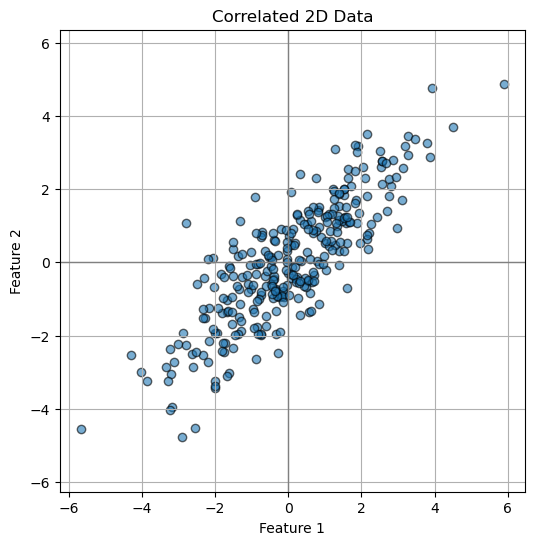

In [ ]:
# making some correlated 2d data
np.random.seed(42)

mean = [0, 0]
cov = [[3, 2.5],
       [2.5, 3]]   

X = np.random.multivariate_normal(mean, cov, 300)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, edgecolors='k')
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title("Correlated 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Variance is basically information</b>
</h2>
<div style="font-family:'Times New Roman';">
The main idea of PCA is honestly pretty simple. The amount a data spreads out along some direction is its variance.
<ul>
<li>if a direction has high variance, it carries a lot of information because points are very different along it</li>
<li>if a direction has almost no variance, it carries very little information because all the points look almost the same there</li>
</ul>
So PCA tries to find the directions where the variance is maximum and then describe the data using those directions.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Finding the direction of maximum variance</b>
</h2>
<div style="font-family:'Times New Roman';">
In our data most of the spread goes along the diagonal. PCA finds that direction on its own and it is called the first principal component or PC1. The second principal component PC2 is perpendicular to it and just captures whatever variance is left.
<br><br>
These directions turn out to be the eigenvectors of the covariance matrix and the variance along each one is its eigenvalue. We will do this properly in the next notebook, here i am just using it to draw the directions.
</div>

In [3]:
# first center the data by subtracting the mean
X_centered = X - X.mean(axis=0)

# covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# eigenvalues and eigenvectors, eigh is used because covariance matrix is symmetric
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# sort them so the biggest variance direction comes first
order = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

print("Eigenvalues (variance along each PC):", eig_vals.round(3))
print("PC1 direction:", eig_vecs[:, 0].round(3))
print("PC2 direction:", eig_vecs[:, 1].round(3))

Eigenvalues (variance along each PC): [5.275 0.467]
PC1 direction: [-0.71  -0.704]
PC2 direction: [ 0.704 -0.71 ]


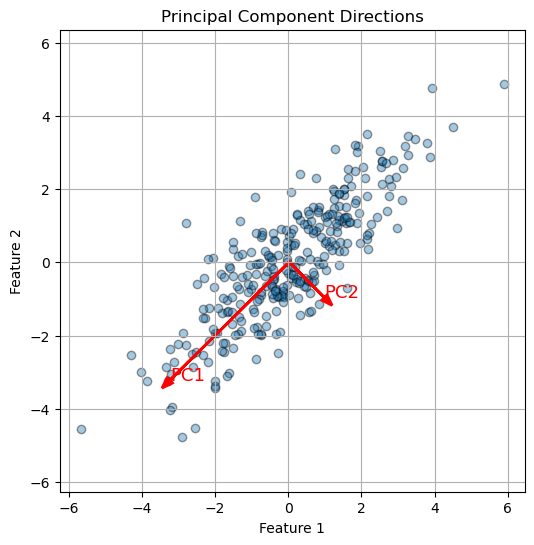

In [4]:
# drawing the two principal component directions over the data
mean_point = X.mean(axis=0)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, edgecolors='k')

for i in range(2):
    # scaling the arrow by sqrt of variance so a longer arrow means more spread
    vec = eig_vecs[:, i] * np.sqrt(eig_vals[i]) * 2
    plt.arrow(mean_point[0], mean_point[1], vec[0], vec[1],
              head_width=0.2, color='red', lw=2)
    plt.text(mean_point[0] + vec[0], mean_point[1] + vec[1],
             f"PC{i+1}", color='red', fontsize=13)

plt.title("Principal Component Directions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Projecting onto the first principal component</b>
</h2>
<div style="font-family:'Times New Roman';">
Reducing dimensions just means projecting the data onto fewer principal components. If we keep only PC1 we go from 2D to 1D, so every point falls onto the PC1 line and becomes a single number which is its position along that line.
<br><br>
We do lose the spread along PC2 but since that was the smaller part of the variation we are not losing much.
</div>

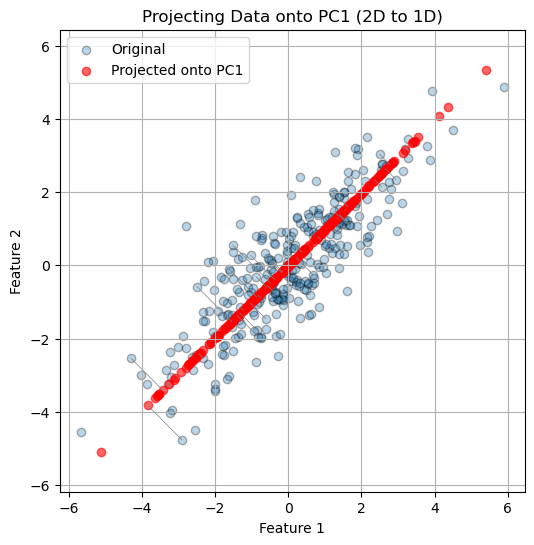

In [5]:
# project the centered data onto PC1
pc1 = eig_vecs[:, 0]
X_proj_1d = X_centered @ pc1            # this is the 1d coordinate along PC1

# bring it back to 2d just so we can plot where the points landed
X_reconstructed = np.outer(X_proj_1d, pc1) + X.mean(axis=0)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, edgecolors='k', label="Original")
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            color='red', alpha=0.6, label="Projected onto PC1")

# few lines to show how the points drop onto the PC1 line
for i in range(0, len(X), 10):
    plt.plot([X[i, 0], X_reconstructed[i, 0]],
             [X[i, 1], X_reconstructed[i, 1]], 'gray', lw=0.5)

plt.title("Projecting Data onto PC1 (2D to 1D)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>How much information did we actually keep?</b>
</h2>
<div style="font-family:'Times New Roman';">
Every principal component keeps some fraction of the total variance. The explained variance ratio tells us how much. For our data PC1 alone keeps most of it, which is exactly why going down to 1D barely hurts.
</div>

In [6]:
explained_variance_ratio = eig_vals / eig_vals.sum()

for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1} keeps {ratio*100:.2f}% of the variance")

print(f"\nKeeping only PC1 still retains "
      f"{explained_variance_ratio[0]*100:.2f}% of the information")

PC1 keeps 91.86% of the variance
PC2 keeps 8.14% of the variance

Keeping only PC1 still retains 91.86% of the information


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The PCA steps </b>
</h2>
<div style="font-family:'Times New Roman';">
Now that the idea is clear, here are the steps we will actually code in the next notebook:
<ol>
<li>standardize the data so all features are on the same scale</li>
<li>compute the covariance matrix</li>
<li>compute the eigenvalues and eigenvectors of that covariance matrix</li>
<li>sort the eigenvectors by their eigenvalue, biggest variance first</li>
<li>pick the top k eigenvectors, these are the principal components</li>
<li>project the data onto these k components</li>
</ol>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>When PCA helps and when it does not</b>
</h2>
<div style="font-family:'Times New Roman';">
PCA is useful when:
<ul>
<li>you have a lot of correlated features</li>
<li>you want to visualize high dimensional data in 2D or 3D</li>
<li>you want to speed up training by using fewer features</li>
<li>you want to cut down some noise</li>
</ul>
But there are some catches too:
<ul>
<li>PCA is linear so it cannot capture curved or non linear structure</li>
<li>the components are mixtures of features so they are harder to interpret</li>
<li>high variance does not always mean the feature is important for prediction</li>
<li>always standardize first otherwise big scale features will dominate</li>
</ul>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Dimensionality reduction is describing the data with fewer features while keeping most of the information</li>
<li>Variance is information, directions with more spread carry more of it</li>
<li>Principal components are new axes (eigenvectors of the covariance matrix) ordered by how much variance they capture</li>
<li>Projection is how we actually reduce dimensions, by dropping points onto the top few components</li>
<li>Explained variance ratio tells how much information each component keeps</li>
</ul>
Next i will build PCA fully from scratch using plain functions, the same way i did the earlier algorithms.
</div>